In [17]:
import torch
from einops import rearrange

batch_size = 16
patch_num = 12
patch_size = 32
num_quantiles = 9

tensor = torch.randn(batch_size, patch_num, num_quantiles * patch_size)
tensor.shape

torch.Size([16, 12, 288])

In [32]:
quantile_preds = rearrange(
    tensor, "b n (q p) -> b q (n p)", n=patch_num, q=num_quantiles, p=patch_size
)

quantile_preds.shape

torch.Size([16, 9, 384])

In [19]:
quantile_preds = rearrange(
    quantile_preds,
    "b q h -> b (q h)",
    b=batch_size,
    q=num_quantiles,
    h=patch_num * patch_size,
)

quantile_preds.shape

torch.Size([16, 3456])

In [20]:
quantiles = torch.linspace(0.1, 0.9, steps=9)
quantiles = rearrange(quantiles, "num_quantiles -> 1 num_quantiles 1")
quantiles.shape

torch.Size([1, 9, 1])

In [37]:
future_target = torch.randn(batch_size, patch_num * patch_size)
print(future_target.shape)

future_target = future_target.unsqueeze(1)  # [batch_size, 1, pred_length]
print(future_target.shape)

future_target_mask = ~torch.isnan(future_target)
print(future_target_mask.shape)
future_target = torch.where(future_target_mask > 0.0, future_target, 0.0)


# pad target and target_mask if they are shorter than model's prediction
if quantile_preds.shape[-1] > future_target.shape[-1]:
    padding_shape = (
        *future_target.shape[:-1],
        quantile_preds.shape[-1] - future_target.shape[-1],
    )
    future_target = torch.cat(
        [future_target, torch.zeros(padding_shape).to(future_target)], dim=-1
    )
    future_target_mask = torch.cat(
        [future_target_mask, torch.zeros(padding_shape).to(future_target_mask)],
        dim=-1,
    )

print(future_target.shape)

torch.Size([16, 384])
torch.Size([16, 1, 384])
torch.Size([16, 1, 384])
torch.Size([16, 1, 384])


In [38]:
quantile_loss = 2 * torch.abs(
    (future_target - quantile_preds)
    * ((future_target <= quantile_preds).float() - quantiles)
)
quantile_loss.shape

torch.Size([16, 9, 384])

In [39]:
quantile_loss.mean(dim=-1).sum(dim=-1).mean()

tensor(10.1867)

tau=0.10 | epoch    0 | loss=0.8364
tau=0.10 | epoch  100 | loss=0.1773
tau=0.10 | epoch  200 | loss=0.0929
tau=0.10 | epoch  300 | loss=0.0858
tau=0.10 | epoch  400 | loss=0.0851
tau=0.10 | epoch  500 | loss=0.0850
tau=0.10 | epoch  600 | loss=0.0850
tau=0.10 | epoch  700 | loss=0.0850
tau=0.50 | epoch    0 | loss=0.5793
tau=0.50 | epoch  100 | loss=0.2018
tau=0.50 | epoch  200 | loss=0.2015
tau=0.50 | epoch  300 | loss=0.2015
tau=0.50 | epoch  400 | loss=0.2015
tau=0.50 | epoch  500 | loss=0.2015
tau=0.50 | epoch  600 | loss=0.2015
tau=0.50 | epoch  700 | loss=0.2015
tau=0.90 | epoch    0 | loss=0.4269
tau=0.90 | epoch  100 | loss=0.0818
tau=0.90 | epoch  200 | loss=0.0817
tau=0.90 | epoch  300 | loss=0.0817
tau=0.90 | epoch  400 | loss=0.0817
tau=0.90 | epoch  500 | loss=0.0817
tau=0.90 | epoch  600 | loss=0.0817
tau=0.90 | epoch  700 | loss=0.0817


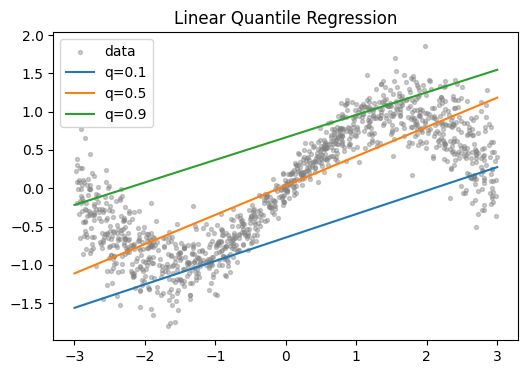

In [1]:
# ------------------------------------------------------------
# 1. 依赖
# ------------------------------------------------------------
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# 2. 造一份 toy 数据：y = sin(x) + ε(x)，噪声随 x 增大而增大
# ------------------------------------------------------------
N = 1200
x_np = np.random.uniform(-3, 3, size=N)
noise = np.random.normal(0, 0.1 * (1 + np.abs(x_np)))  # 异方差
y_np = np.sin(x_np) + noise
X = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1).to(device)  # shape (N,1)
Y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1).to(device)  # shape (N,1)


# ------------------------------------------------------------
# 3. 定义模型：只有一个线性层（输入 1 → 输出 1）
# ------------------------------------------------------------
class LinearQuantileNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)  # 纯线性，无激活

    def forward(self, x):
        return self.linear(x)  # shape (batch,1)


# ------------------------------------------------------------
# 4. Pinball loss
# ------------------------------------------------------------
def quantile_loss(y_pred, y_true, tau):
    """
    y_pred, y_true: tensor of shape (batch, 1)
    tau: float, 目标分位水平 ∈ (0,1)
    """
    e = y_true - y_pred
    return torch.mean(torch.maximum(tau * e, (tau - 1) * e))


# ------------------------------------------------------------
# 5. 辅助：为每个分位水平训练一个模型
# ------------------------------------------------------------
def train_one_quantile(tau, lr=1e-2, epochs=800):
    model = LinearQuantileNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        opt.zero_grad()
        pred = model(X)
        loss = quantile_loss(pred, Y, tau)
        loss.backward()
        opt.step()
        if epoch % 100 == 0:
            print(f"tau={tau:.2f} | epoch {epoch:4d} | loss={loss.item():.4f}")
    return model


# ------------------------------------------------------------
# 6. 训练 3 个分位水平
# ------------------------------------------------------------
quantiles = [0.1, 0.5, 0.9]
models = {q: train_one_quantile(q) for q in quantiles}


import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ------------------------------------------------------------
# 7. 可视化
# ------------------------------------------------------------
xx = torch.linspace(-3, 3, 200).unsqueeze(1).to(device)
with torch.no_grad():
    plt.figure(figsize=(6, 4))
    plt.scatter(x_np, y_np, s=8, color="gray", alpha=0.4, label="data")
    for q in quantiles:
        yy = models[q](xx).cpu().numpy()
        plt.plot(xx.cpu(), yy, label=f"q={q}")
    plt.legend()
    plt.title("Linear Quantile Regression")
    plt.show()

In [ ]:
quantiles = torch.linspace(0.1, 0.9, steps=9)
quantiles = rearrange(quantiles, "num_quantiles -> 1 num_quantiles 1")
quantiles.shape

In [9]:
from einops import rearrange

num_quantiles = 9
quantiles = torch.linspace(0.1, 0.9, steps=9)
quantiles = rearrange(quantiles, "num_quantiles -> 1 num_quantiles")

model = nn.Sequential(nn.Linear(1, 64), nn.ReLU(), nn.Linear(64, num_quantiles))


opt = torch.optim.Adam(model.parameters(), lr=1e-2)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5)
for epoch in range(3000):
    opt.zero_grad()
    pred = model(X)  # [batch_size, num_quantiles]
    # Y: [batch_size, 1]

    quantile_loss = 2 * torch.abs((Y - pred) * ((Y <= pred).float() - quantiles))
    loss = quantile_loss.mean(dim=-1).sum(dim=-1).mean()
    loss.backward()
    opt.step()
    if epoch % 100 == 0:
        print(f"epoch {epoch:4d} | loss={loss.item():.4f}")

    sch.step()

epoch    0 | loss=816.1697
epoch  100 | loss=186.8953
epoch  200 | loss=185.7895
epoch  300 | loss=185.5863
epoch  400 | loss=185.5349
epoch  500 | loss=185.5204
epoch  600 | loss=185.5168
epoch  700 | loss=185.5158
epoch  800 | loss=185.5155
epoch  900 | loss=185.5155
epoch 1000 | loss=185.5155
epoch 1100 | loss=185.5154
epoch 1200 | loss=185.5154
epoch 1300 | loss=185.5154
epoch 1400 | loss=185.5154
epoch 1500 | loss=185.5154
epoch 1600 | loss=185.5154
epoch 1700 | loss=185.5154
epoch 1800 | loss=185.5154
epoch 1900 | loss=185.5154
epoch 2000 | loss=185.5154
epoch 2100 | loss=185.5154
epoch 2200 | loss=185.5154
epoch 2300 | loss=185.5154
epoch 2400 | loss=185.5154
epoch 2500 | loss=185.5154
epoch 2600 | loss=185.5154
epoch 2700 | loss=185.5154
epoch 2800 | loss=185.5154
epoch 2900 | loss=185.5154


In [35]:
quantiles

tensor([[0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000]])

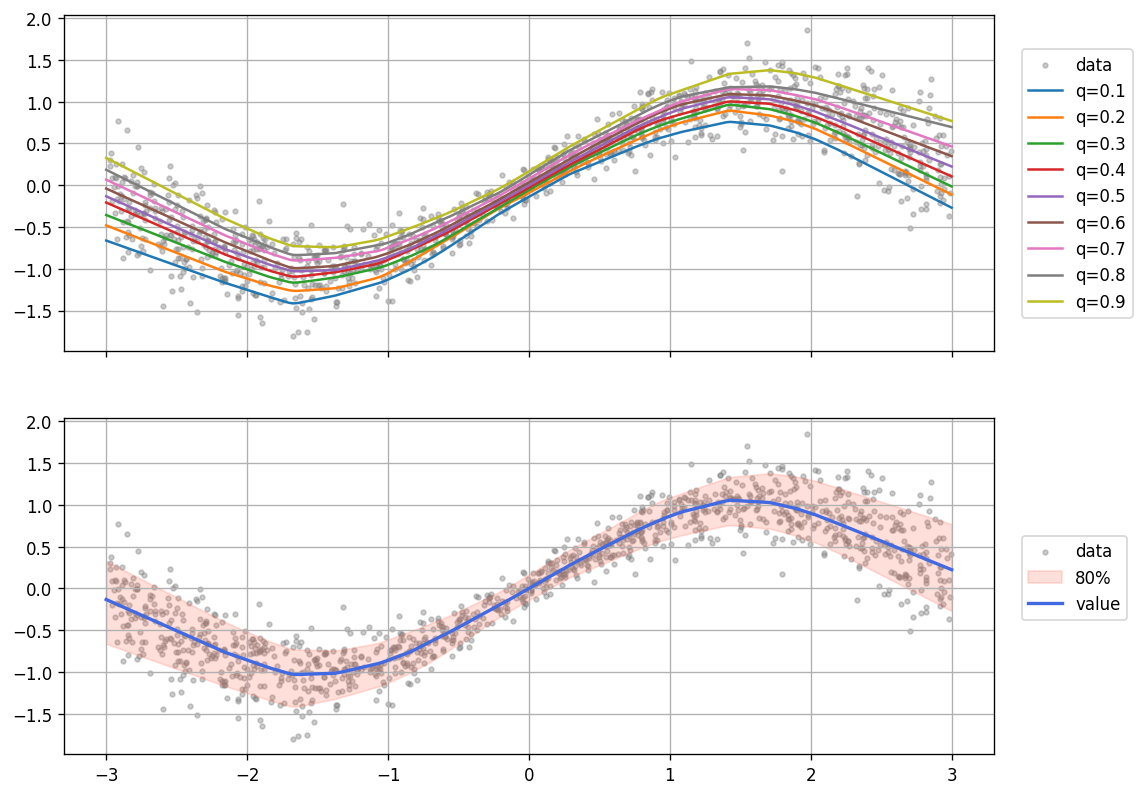

In [50]:
xx = torch.linspace(-3, 3, 200).unsqueeze(1).to(device)

with torch.no_grad():
    yy = model(xx).cpu().numpy()  # [200, num_quantiles]

# plt.figure(figsize=(7, 4), dpi=120)
# plt.scatter(x_np, y_np, s=8, color="gray", alpha=0.4, label="data")

# for i in range(num_quantiles):
#     plt.plot(xx.cpu(), yy[:, i], label=f"q={quantiles[0,i].item():.1f}")
#     plt.legend(loc=(1.03, 0.1))
#     plt.title("Neural Network Quantile Regression")
#     plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=120, sharex=True)

ax[0].grid(True)
ax[1].grid(True)

ax[0].scatter(x_np, y_np, s=8, color="gray", alpha=0.4, label="data")
ax[1].scatter(x_np, y_np, s=8, color="gray", alpha=0.4, label="data")
for i in range(num_quantiles):
    ax[0].plot(xx.cpu(), yy[:, i], label=f"q={quantiles[0,i].item():.1f}")
    ax[0].legend(loc=(1.03, 0.1))

ax[1].fill_between(
    xx.cpu().squeeze(), yy[:, 0], yy[:, -1], color="tomato", label="80%", alpha=0.2
)
ax[1].plot(xx, yy[:, 4], color="royalblue", linewidth=2, label="value")

ax[1].legend(loc=(1.03, 0.4))